# Setup for Paper II


### Setup notebook

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

### Imports

In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim libraries
import platosim.plot      as pt
import platosim.starquery as sq
import platosim.utilities as ut
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [3]:
# Platform pointing
alpha, delta, kappa = ut.getPointingField('LOPS2')

---
## Create HRD from Gaia DR3 CMD
---

First the full Gaia DR3 catalogue for the LOPS2 is generated using:
```
picsim --vizier LOPS2 --project paperII -p
```

In [4]:
# idir = '/lhome/nicholas/software/workdir/paperII/input'
idir = '/lhome/nicholas/software/workdir/test/input'
df1 = pd.read_feather(f"{idir}/starcat_GaiaDR3_LOPS2_group1.ftr")
df2 = pd.read_feather(f"{idir}/starcat_GaiaDR3_LOPS2_group2.ftr")
df3 = pd.read_feather(f"{idir}/starcat_GaiaDR3_LOPS2_group3.ftr")
df4 = pd.read_feather(f"{idir}/starcat_GaiaDR3_LOPS2_group4.ftr")

In [5]:
# Combine each 
df = pd.concat([df1, df2, df3, df4])

In [6]:
# Remove all targets without Teff and logg info
df = df.dropna()

In [7]:
# Remove duplicates
df = df.drop_duplicates()

<IPython.core.display.Javascript object>


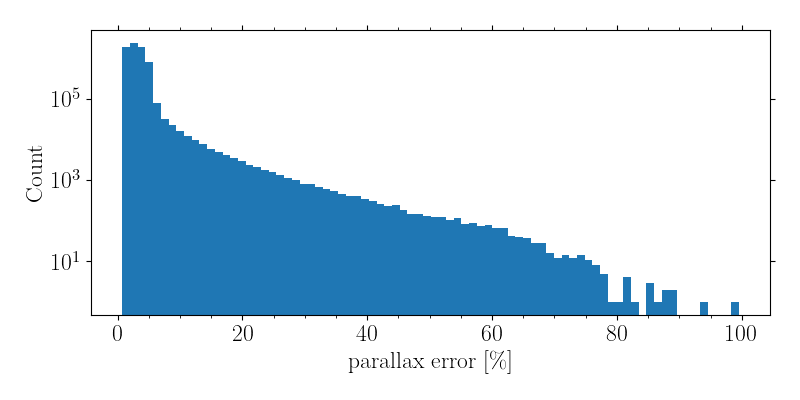

In [8]:
# Inspect uncertainties
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(df.plx_err*100, bins=80)
ax.set_xlabel('parallax error [\%]')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

In [10]:
# Remove stars with high uncertainty in parallax
df = df.drop(df[df.plx_err > 0.8].index)

# Remove stars without color information
df = df.drop(df[df.bp_rp == 0].index)

<IPython.core.display.Javascript object>


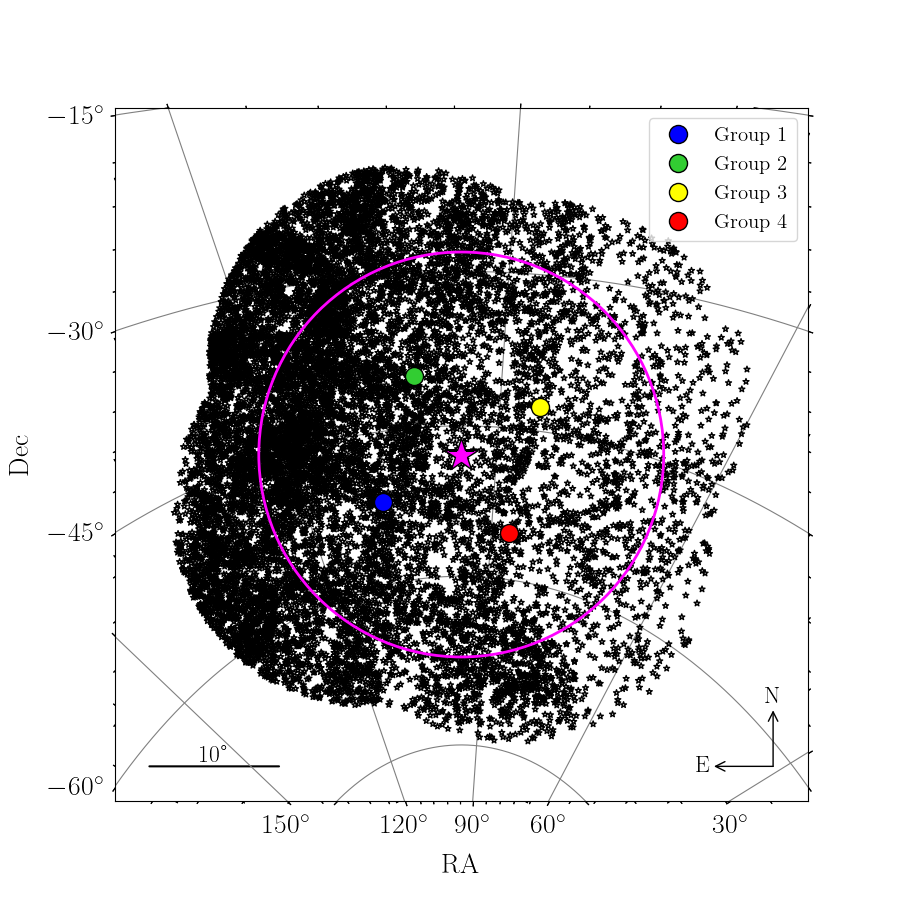

In [11]:
# Show stars detected on the CCDs in an aitoff sky projection 
df0 = df.sample(frac = 1)
df0 = df0.iloc[::500]
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=df0.ra.to_numpy(), decStars=df0.dec.to_numpy(), magStars=None, 
                          system="icrs", showGroups=True, ncamStars=False, fovSize=35, fs=20, figsize=(9,9))

<IPython.core.display.Javascript object>


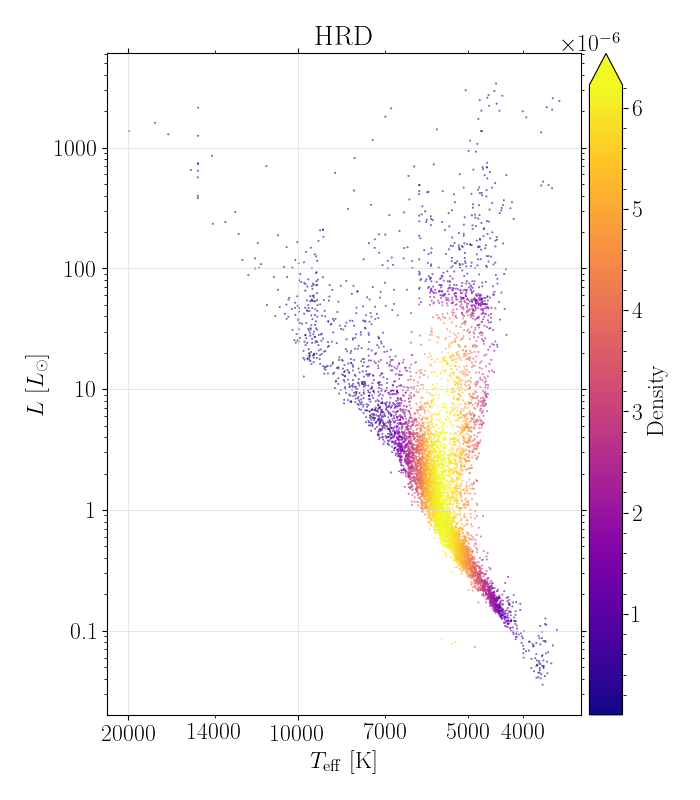

In [67]:
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mticker

# Plot HRD
ds = df.iloc[::1000]
fig, ax = plt.subplots(1,1, figsize=(7,8))
x, y, z = ut.sortAfterDensity(ds.teff.to_numpy(), ds.lum.to_numpy())
im = ax.scatter(x, y, c=z, s=0.1, alpha=1, cmap="plasma")
cbar = fig.colorbar(im, extend='max', shrink=1, pad=0.015)                     
cbar.set_label('Density', labelpad=3)                                    
cbar.ax.tick_params()

ax.set_title('HRD')
ax.set_xlabel(r'$T_{\rm eff}$ [K]')
ax.set_ylabel(r'$L$ [$L_{\odot}$]')
ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()

# We change the fontsize of major and minor ticks label 
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.16g}'.format(y)))
ticks_major = [20000, 10000]
ax.xaxis.set_major_locator(mticker.FixedLocator(ticks_major))
ax.set_xticklabels(ticks_major)
ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, _: '{:.16g}'.format(x)))
ticks_minor = [14000, 7000, 5000, 4000]
ax.xaxis.set_minor_locator(mticker.FixedLocator(ticks_minor))

# Settings
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


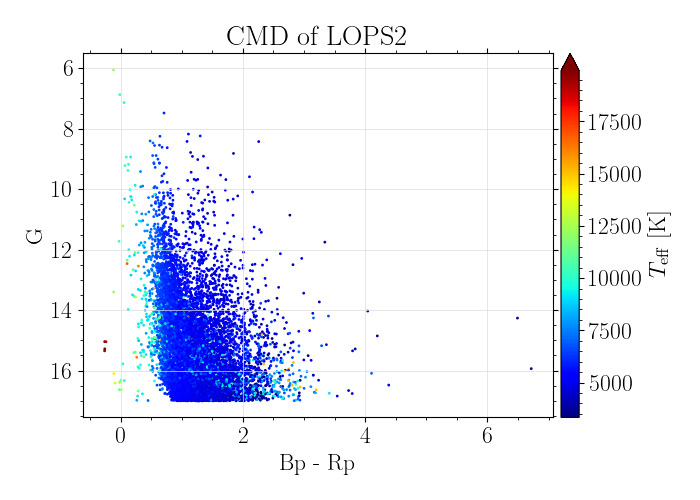

<IPython.core.display.Javascript object>


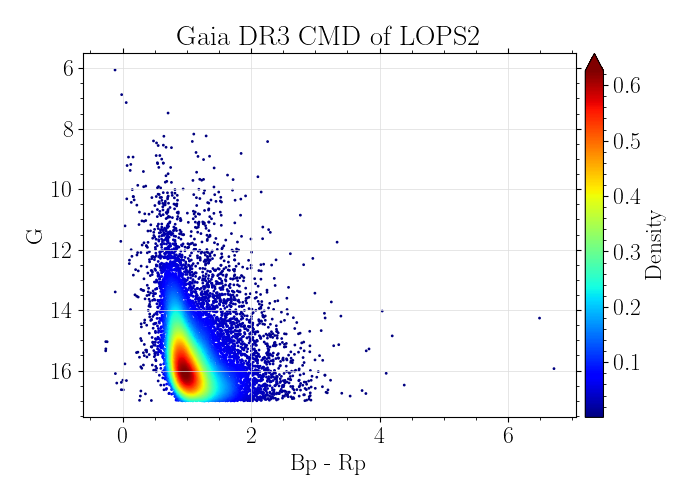

In [47]:
# Plot CMD
fig, ax = plt.subplots(1,1, figsize=(7,5))
im = ax.scatter(df0.bp_rp, df0.mag, c=df0.teff, s=1, cmap="jet")
cbar = fig.colorbar(im, extend='max', shrink=1, pad=0.015)                     
cbar.set_label(r"$T_{\rm eff}$ [K]", labelpad=3)                                    
cbar.ax.tick_params()
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
ax.set_title('CMD of LOPS2')
ax.set_xlabel('Bp - Rp')
ax.set_ylabel('G')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1,1, figsize=(7,5))
x, y, z = ut.sortAfterDensity(df0.bp_rp.to_numpy(), df0.mag.to_numpy())
im = ax.scatter(x, y, c=z, s=1, alpha=1, cmap="jet")
cbar = fig.colorbar(im, extend='max', shrink=1, pad=0.015)                     
cbar.set_label("Density", labelpad=3)                                    
cbar.ax.tick_params()
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
ax.set_title('Gaia DR3 CMD of LOPS2')
ax.set_xlabel('Bp - Rp')
ax.set_ylabel('G')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


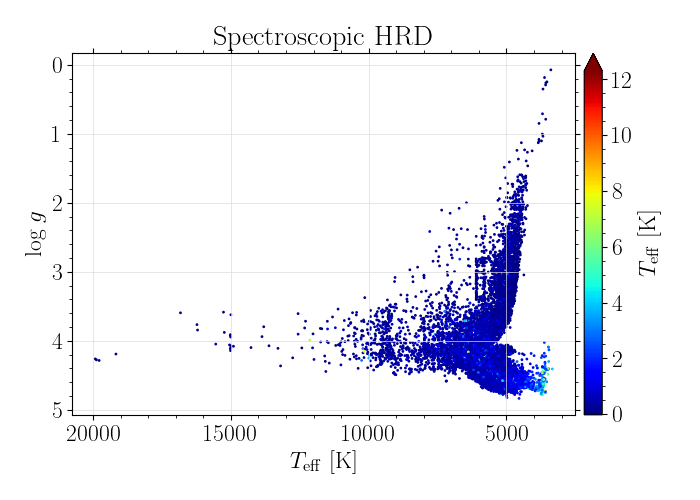

<IPython.core.display.Javascript object>


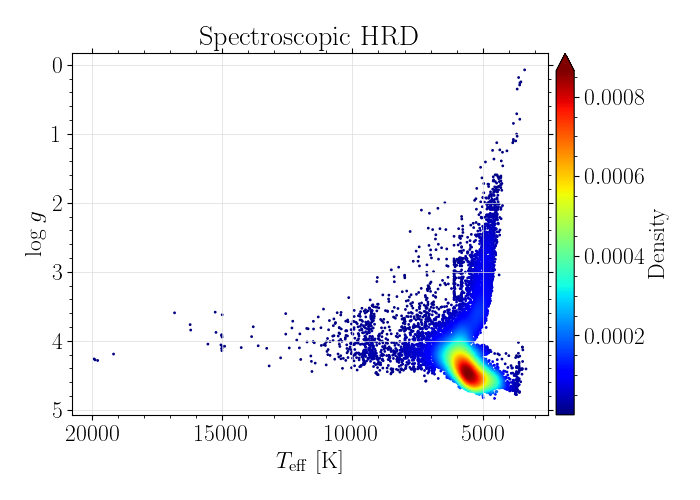

In [48]:
# Plot spectroscopic HRD
fig, ax = plt.subplots(1,1, figsize=(7,5))
im = ax.scatter(df0.teff, df0.logg, c=df0.plx, s=1, cmap="jet")
cbar = fig.colorbar(im, extend='max', shrink=1, pad=0.015)                     
cbar.set_label(r"$T_{\rm eff}$ [K]", labelpad=3)                                    
cbar.ax.tick_params()
ax.set_title('Spectroscopic HRD')
ax.set_xlabel(r'$T_{\rm eff}$ [K]')
ax.set_ylabel(r'log $g$')
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# Plot 
fig, ax = plt.subplots(1,1, figsize=(7,5))
x, y, z = ut.sortAfterDensity(df0.teff.to_numpy(), df0.logg.to_numpy())
im = ax.scatter(x, y, c=z, s=1, alpha=1, cmap="jet")
cbar = fig.colorbar(im, extend='max', shrink=1, pad=0.015)                     
cbar.set_label('Density', labelpad=3)                                    
cbar.ax.tick_params()
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
ax.set_title('Spectroscopic HRD')
ax.set_xlabel(r'$T_{\rm eff}$ [K]')
ax.set_ylabel(r'log $g$')
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


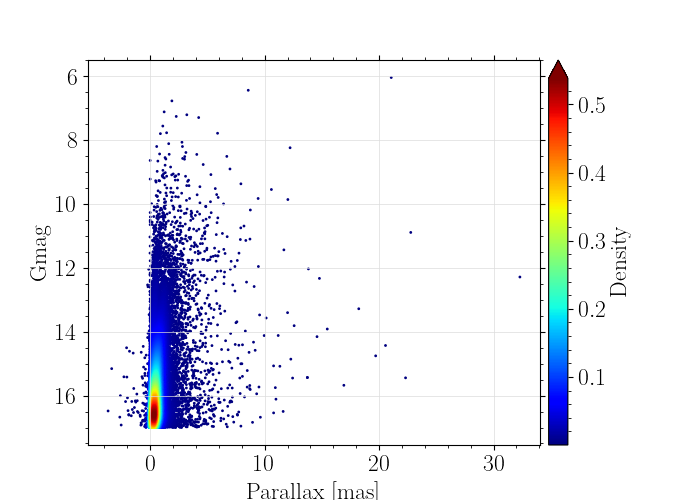

In [29]:
fig, ax = plt.subplots(1,1, figsize=(7,5))
x, y, z = ut.sortAfterDensity(df0.plx.to_numpy(), df0.mag.to_numpy())
im = ax.scatter(x, y, c=z, s=1, alpha=1, cmap='jet')
cbar = fig.colorbar(im, extend='max', shrink=1, pad=0.015)                     
cbar.set_label("Density", labelpad=3)                                    
cbar.ax.tick_params()
ax.set_xlabel('Parallax [mas]')
ax.set_ylabel('Gmag')
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
# ax.set_xlim(-75, +100)
# ax.set_ylim(-75, 50)
ax.invert_yaxis()
plt.show()

<IPython.core.display.Javascript object>


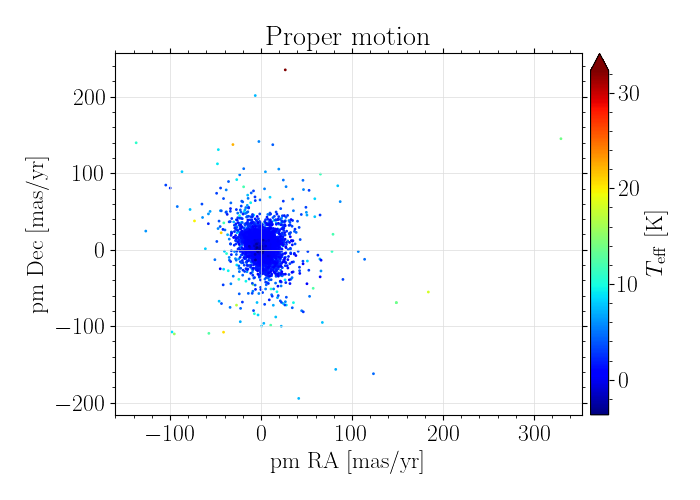

<IPython.core.display.Javascript object>


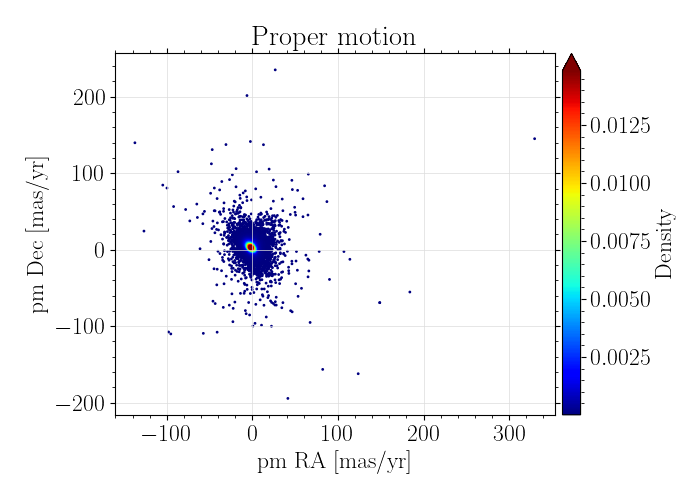

In [35]:
fig, ax = plt.subplots(1,1, figsize=(7,5))
df1 = df0.sort_values(['plx'], ascending=[False])
im = ax.scatter(df1.pmra, df1.pmdec, c=df1.plx, s=1, cmap="jet")
cbar = fig.colorbar(im, extend='max', shrink=1, pad=0.015)                     
cbar.set_label(r"$T_{\rm eff}$ [K]", labelpad=3)                                    
cbar.ax.tick_params()
ax.set_title('Proper motion')
ax.set_xlabel('pm RA [mas/yr]')
ax.set_ylabel('pm Dec [mas/yr]')
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1,1, figsize=(7,5))
x, y, z = ut.sortAfterDensity(df1.pmra.to_numpy(), df1.pmdec.to_numpy())
im = ax.scatter(x, y, c=z, s=1, alpha=1, cmap='jet')
cbar = fig.colorbar(im, extend='max', shrink=1, pad=0.015)                     
cbar.set_label("Density", labelpad=3)                                    
cbar.ax.tick_params()
ax.set_title('Proper motion')
ax.set_xlabel('pm RA [mas/yr]')
ax.set_ylabel('pm Dec [mas/yr]')
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
# ax.set_xlim(-75, +100)
# ax.set_ylim(-75, 50)
plt.tight_layout()
plt.show()

---
## Grid of high resolution spectra
---

In [124]:
import astropy.io.fits as fits
hdul = fits.open('/lhome/nicholas/ckm05_10000.fits')
df = pd.DataFrame(hdul[1].data)


WAVELENGTH    90.900002
g00            0.000000
g05            0.000000
g10            0.000000
g15            0.000000
g20            0.000000
g25            0.000000
g30            0.000000
g35            0.000000
g40            0.000000
g45            0.000000
g50            0.000000
Name: 0, dtype: float32

<IPython.core.display.Javascript object>


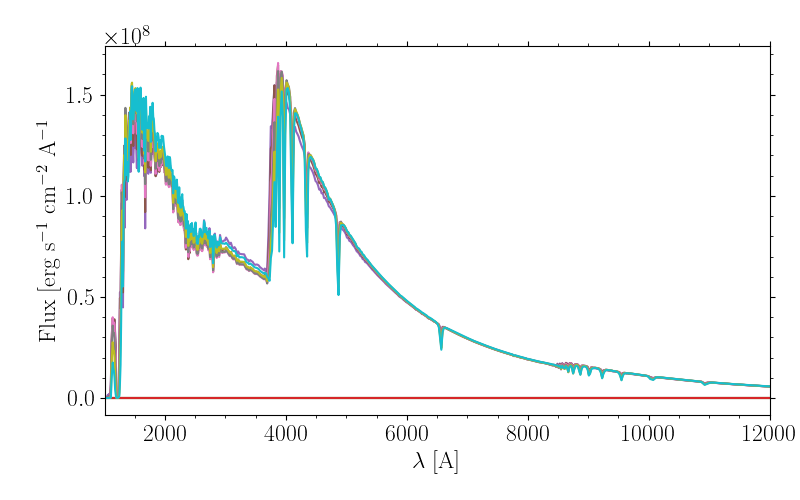

(1000.0, 12000.0)

In [86]:
fig, ax = plt.subplots(1,1,figsize=(8,5))

for i in range(1, len(df.iloc[0])-1):
    ax.plot(df.WAVELENGTH, df.iloc[:,i], '-')

ax.set_xlabel(r'$\lambda$ [A]')
ax.set_ylabel('Flux [erg s$^{-1}$ cm$^{-2}$ A$^{-1}$]')
plt.tight_layout()
ax.set_xlim(1000, 12000)

In [109]:
from platosim.phoenix import Atlas9
atlas = Atlas9()

In [113]:
Teff, logg, Z, alpha = atlas.nearest_parameters(15000, 3.0, 0.0, 0.0)

In [120]:
wvl1_in, flux1_in = atlas.getFITS(Teff, logg, Z, alpha)

In [31]:
valid_t_phoenix = np.array([*list(range(2300, 7000, 100)), 
                            *list((range(7000, 12200, 200)))])
valid_g_phoenix = np.array([*list(np.arange(0, 6, 0.5))])

valid_t_atlas9 = np.array([*list(range(3000, 1300, 250)), 
                           *list((range(13000, 50000, 1000)))])

<IPython.core.display.Javascript object>


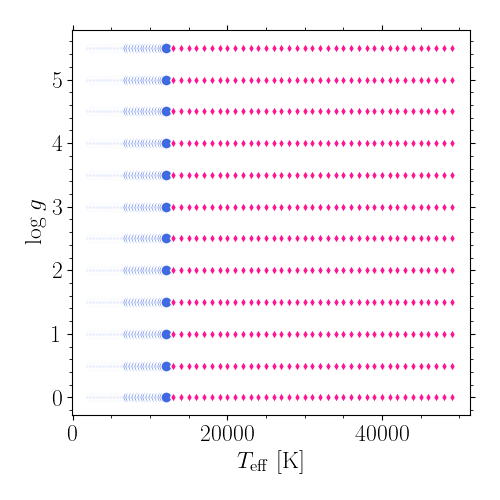

In [34]:
fig, ax = plt.subplots(1,1,figsize=(5,5))

for i in range(len(valid_g)):
    ax.plot(valid_t_phoenix, np.ones_like(valid_t_phoenix)*valid_g_phoenix[i], 
            'o', c='royalblue', mec='w', ms=8)
    ax.plot(valid_t_atlas9,  np.ones_like(valid_t_atlas9)*valid_g_phoenix[i], 
            'd', c='deeppink', mec='w', ms=5)
    
ax.set_xlabel(r'$T_{\rm eff}$ [K]')
ax.set_ylabel('log $g$')
plt.tight_layout()